In [25]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap


In [26]:
df_train = pd.read_csv("C:/Users/mutch_lf652j0/Credit Score Interactive Model/data/processed/cleaned_train.csv")
df_test = pd.read_csv("C:/Users/mutch_lf652j0/Credit Score Interactive Model/data/processed/cleaned_test.csv")

In [27]:
df_train.head()

,age,annual_income,employment_length_years,home_ownership,region,num_open_accounts,num_delinquencies_2yr,total_revolving_balance,credit_utilisation_pct,months_since_oldest_account,...,interest_rate,loan_purpose,dti_ratio,months_since_last_delinquency,pct_accounts_current,application_dow,email_domain_type,default_flag,missing_annual_income,missing_months_since_last_delinquency
0,25.0,32005.0,1.4,MORTGAGE,South-Urban,10.0,0,0.0,31.2,42.0,...,12.69,medical,0.337,105.0,93.0,Friday,free,0,0,0
1,23.9,25010.0,4.0,MORTGAGE,North-Urban,6.0,1,3962.0,70.8,55.0,...,16.56,debt_consolidation,0.294,96.0,84.5,Thursday,corporate,1,0,0
2,52.5,39710.0,7.9,MORTGAGE,East-Urban,6.0,1,1630.0,66.6,281.0,...,13.22,home_improvement,0.214,37.0,57.2,Wednesday,free,0,0,0
3,48.2,49147.0,12.3,RENT,Central-Urban,6.0,0,4414.0,57.3,237.0,...,11.55,medical,0.137,900.0,92.5,Wednesday,corporate,0,0,1
4,45.1,100583.0,3.4,RENT,North-Suburban,8.0,0,2985.0,33.7,224.0,...,8.12,debt_consolidation,0.050,900.0,78.4,Monday,free,0,0,1


In [28]:
df_train.columns.tolist()

['age',
 'annual_income',
 'employment_length_years',
 'home_ownership',
 'region',
 'num_open_accounts',
 'num_delinquencies_2yr',
 'total_revolving_balance',
 'credit_utilisation_pct',
 'months_since_oldest_account',
 'num_hard_inquiries_6mo',
 'loan_amount',
 'interest_rate',
 'loan_purpose',
 'dti_ratio',
 'months_since_last_delinquency',
 'pct_accounts_current',
 'application_dow',
 'email_domain_type',
 'default_flag',
 'missing_annual_income',
 'missing_months_since_last_delinquency']

In [29]:
#lets start with a few helpful financial ratios that we can create from the existing features. Some are commonly used in credit scoring models and should help our model learn some useful patterns in the data.

In [30]:
df_train["months_since_last_delinquency"].nunique()

176

In [31]:

#Monthly debt payments relative to income
df_train['loan_to_income'] = df_train['loan_amount'] / df_train['annual_income']
#Total revolving balance relative to income
df_train['revolving_balance_to_income'] = df_train['total_revolving_balance'] / df_train['annual_income']
#interest cost relative to income
df_train['interest_to_income'] = (df_train['loan_amount'] * df_train['interest_rate']) / df_train['annual_income']

#credit history relative to age, this may solve the multicolinearity issue and create a more useful feature for the model to learn from
df_train["credit_history_to_age"] = df_train["months_since_oldest_account"] / (df_train["age"] *12)

#delinquency rate accross open accounts
df_train["delinquency_rate"] = df_train["num_delinquencies_2yr"] / (df_train["num_open_accounts"] + 1)

#Multiplying effect of hard inquiries and delinquencies.
df_train['hard_inquiries_delinquencies'] = df_train['num_hard_inquiries_6mo'] * df_train['num_delinquencies_2yr']
df_train['hard_inquiries_delinquencies'] = pd.cut(
    df_train['hard_inquiries_delinquencies'],
    bins=[-1, 0, 2, 6, float('inf')],
    labels=[0, 1, 2, 3])

#lets categorise the delinquency risk based on number of months.

delinquent_mask = df_train['months_since_last_delinquency'] != 900

df_train['delinquency_recency_bucket'] = 0  # default = never delinquent

df_train.loc[delinquent_mask, 'delinquency_recency_bucket'] = pd.qcut(
    df_train.loc[delinquent_mask, 'months_since_last_delinquency'],
    q=3,
    labels=[3, 2, 1]  # 3=most recent/risky, 1=oldest/least risky
)

#high dti and high interest is a risky combination.
df_train["rate_dti_burden"] = df_train["interest_rate"] * df_train["dti_ratio"]

#rate multiplied with delinquency risk.  
df_train['rate_delinquency_risk'] = df_train['interest_rate'] * df_train['num_delinquencies_2yr']

#younger borrower with high interest may be riskier.
df_train['rate_to_age'] = df_train['interest_rate'] / df_train['age']







In [32]:
# Monthly debt payments relative to income
df_test['loan_to_income'] = df_test['loan_amount'] / df_test['annual_income']

# Total revolving balance relative to income
df_test['revolving_balance_to_income'] = df_test['total_revolving_balance'] / df_test['annual_income']

# Interest cost relative to income
df_test['interest_to_income'] = (df_test['loan_amount'] * df_test['interest_rate']) / df_test['annual_income']

# Credit history relative to age
df_test["credit_history_to_age"] = df_test["months_since_oldest_account"] / (df_test["age"] * 12)

# Delinquency rate across open accounts
df_test["delinquency_rate"] = df_test["num_delinquencies_2yr"] / (df_test["num_open_accounts"] + 1)

# Multiplying effect of hard inquiries and delinquencies
df_test['hard_inquiries_delinquencies'] = df_test['num_hard_inquiries_6mo'] * df_test['num_delinquencies_2yr']
df_test['hard_inquiries_delinquencies'] = pd.cut(
    df_test['hard_inquiries_delinquencies'],
    bins=[-1, 0, 2, 6, float('inf')],
    labels=[0, 1, 2, 3])

# Delinquency recency bucket 
_, bin_edges = pd.qcut(
    df_train.loc[df_train['months_since_last_delinquency'] != 900, 'months_since_last_delinquency'],
    q=3, retbins=True
)

test_delinquent_mask = df_test['months_since_last_delinquency'] != 900
df_test['delinquency_recency_bucket'] = 0
df_test.loc[test_delinquent_mask, 'delinquency_recency_bucket'] = pd.cut(
    df_test.loc[test_delinquent_mask, 'months_since_last_delinquency'],
    bins=bin_edges,
    labels=[3, 2, 1],
    include_lowest=True
)

# High dti and high interest is a risky combination
df_test["rate_dti_burden"] = df_test["interest_rate"] * df_test["dti_ratio"]

# Rate multiplied with delinquency risk
df_test['rate_delinquency_risk'] = df_test['interest_rate'] * df_test['num_delinquencies_2yr']

# Younger borrower with high interest may be riskier
df_test['rate_to_age'] = df_test['interest_rate'] / df_test['age']

In [33]:
df_train = df_train.drop(columns= ['home_ownership', 'region','loan_purpose','application_dow','email_domain_type'])
df_test = df_test.drop(columns= ['home_ownership', 'region','loan_purpose','application_dow','email_domain_type'])


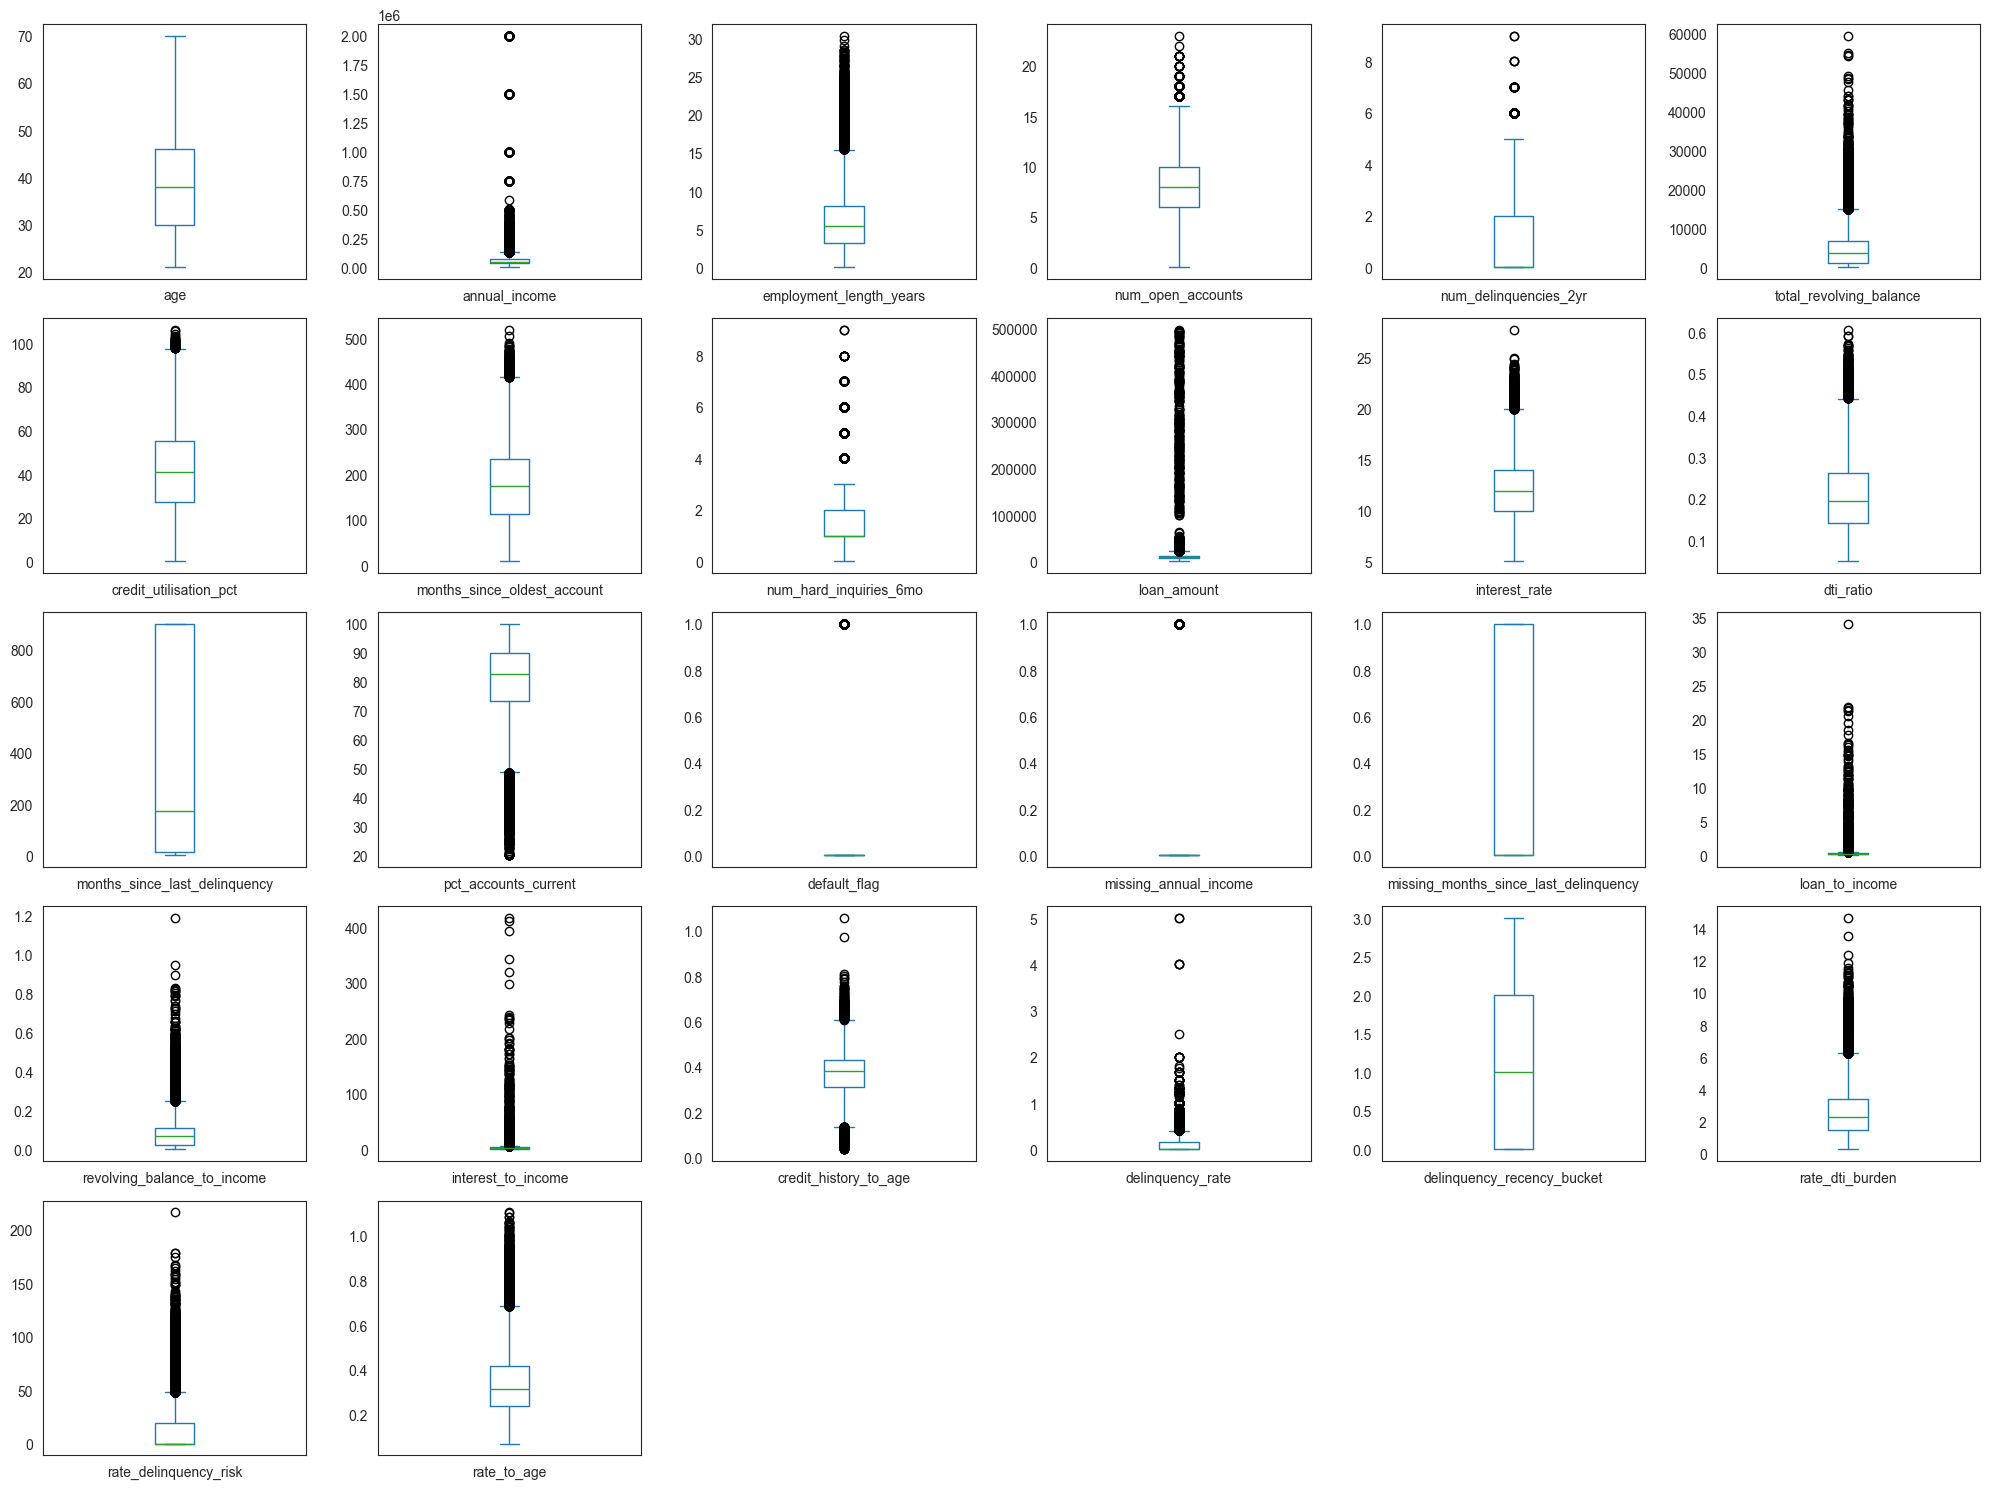

In [34]:
df_train.select_dtypes(include='number').plot(
    kind='box', subplots=True, figsize=(20, 15), layout=(5, 6))
plt.tight_layout()
plt.show()

In [35]:
#lets remove outliers, by capping values at Q1 - 1.5*IQR and Q3 + 1.5*IQR

def cap_outliers(df_train, df_test, cols, factor = 3):
    for col in cols:
        Q1 = df_train[col].quantile(0.25)
        Q3 = df_train[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - factor * IQR
        upper_bound = Q3 + factor * IQR
        
        df_train[col] = df_train[col].clip(lower=lower_bound, upper=upper_bound)
        df_test[col] = df_test[col].clip(lower=lower_bound, upper=upper_bound)

    return df_train, df_test

cols_to_cap = ['annual_income', 'loan_amount', 'total_revolving_balance',
               'interest_to_income', 'rate_delinquency_risk', 'loan_to_income',
               'employment_length_years', 'num_hard_inquiries_6mo',
               'revolving_balance_to_income']

df_train, df_test = cap_outliers(df_train, df_test, cols_to_cap)

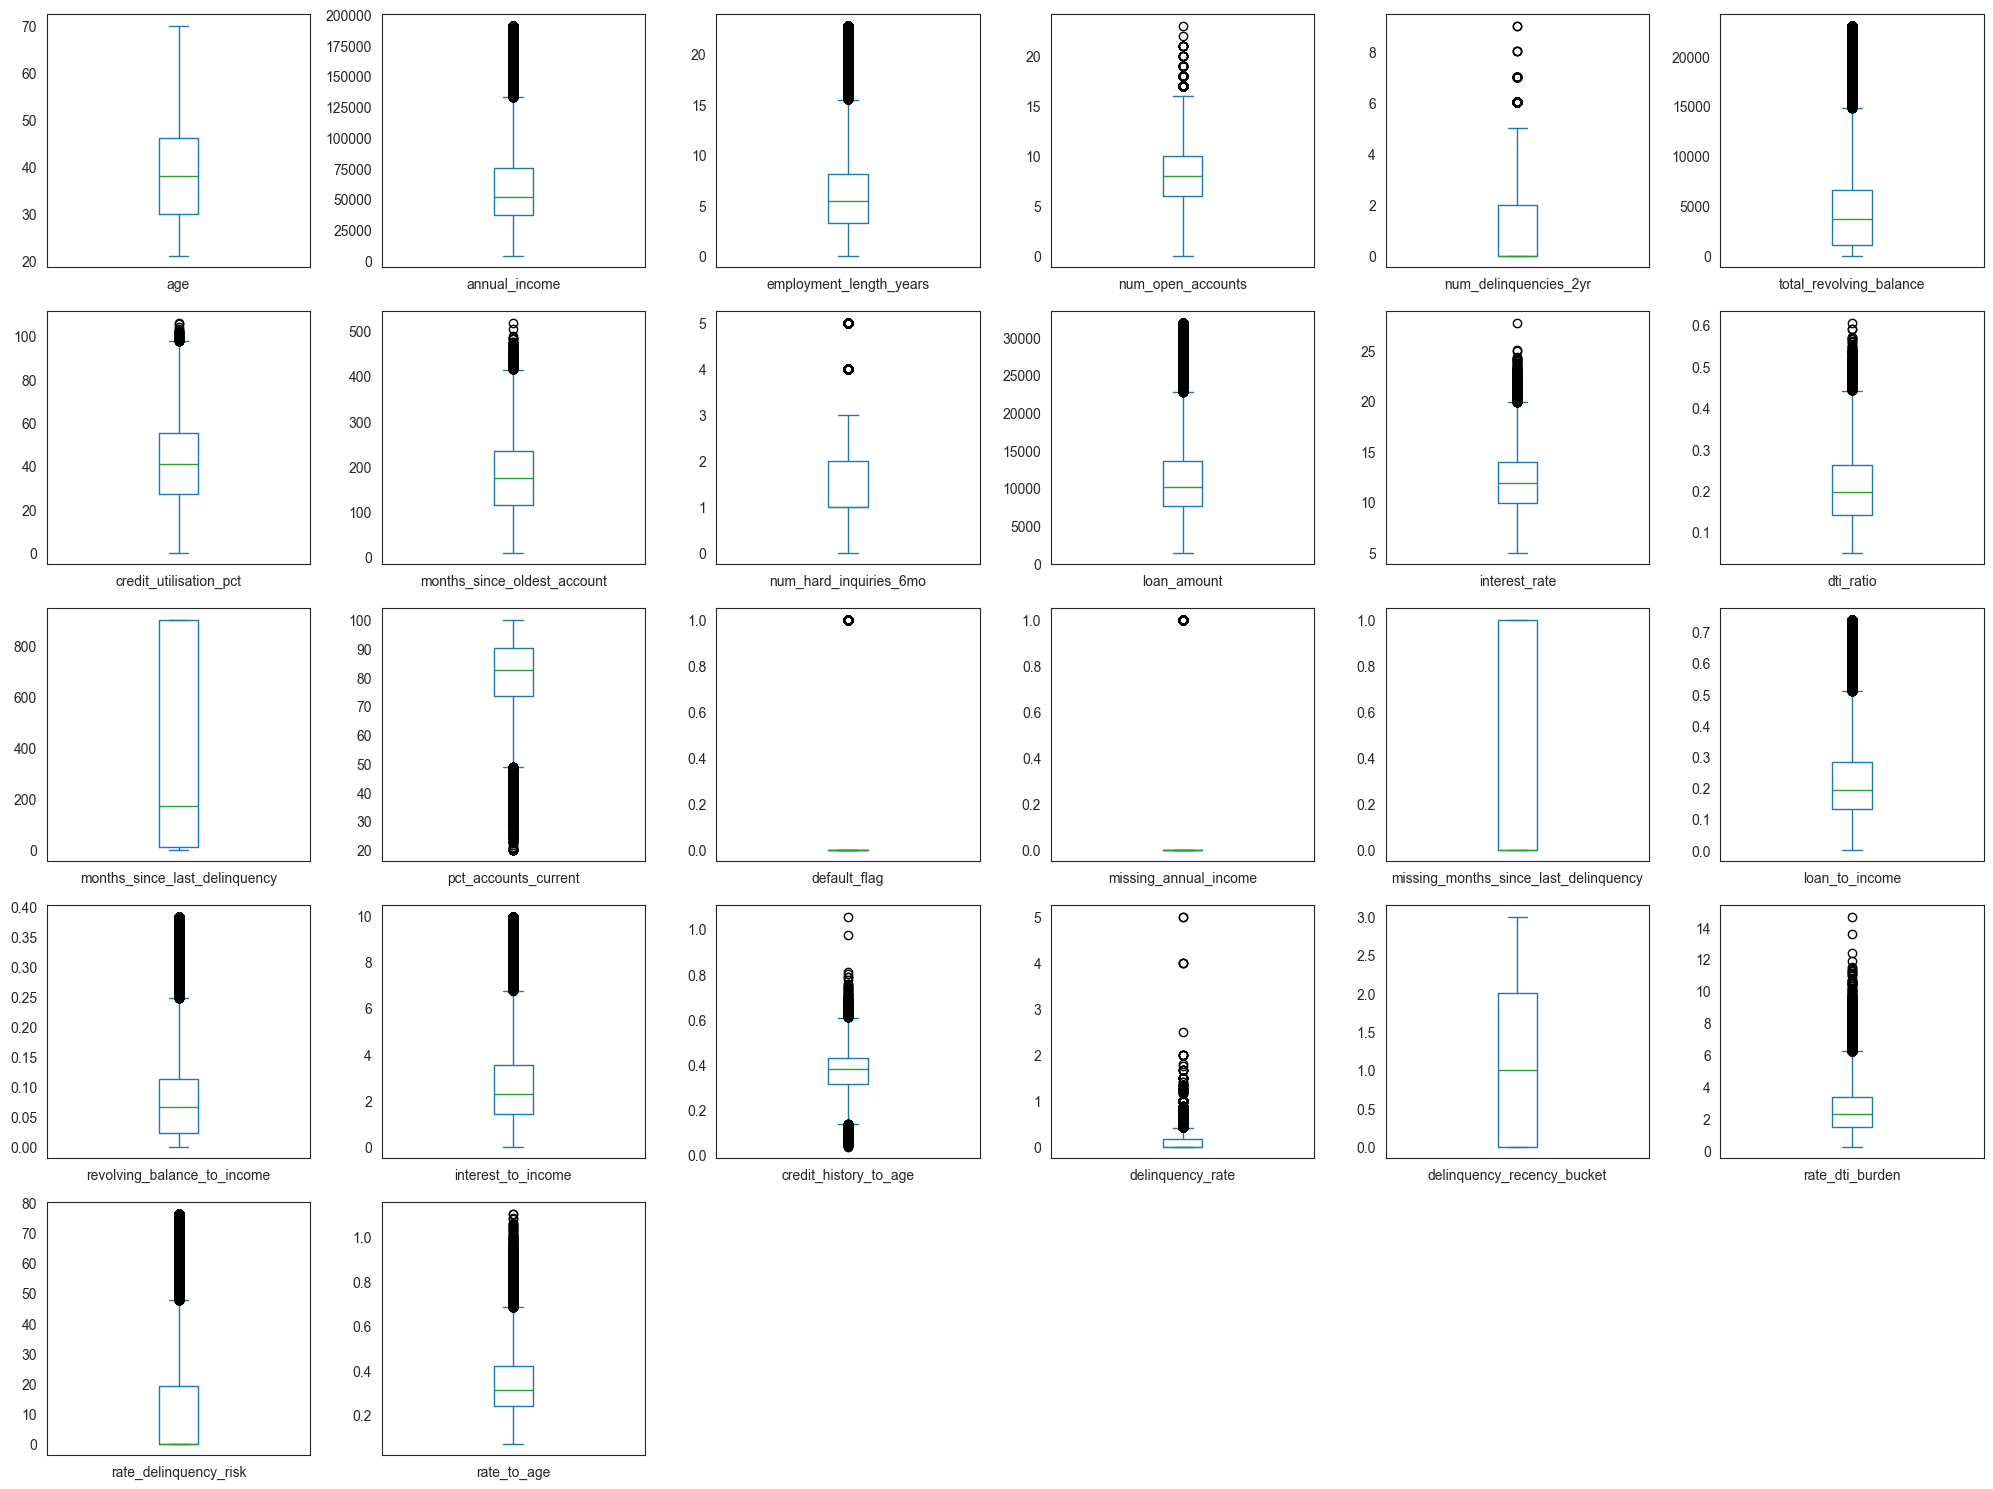

In [36]:
df_train.select_dtypes(include='number').plot(
    kind='box', subplots=True, figsize=(20, 15), layout=(5, 6))
plt.tight_layout()
plt.show()

In [37]:
#log transformations for skewed features, leave out binary and normally distributed columns

In [38]:
log_transform_cols = ['annual_income', 'loan_amount', 'total_revolving_balance',
            'interest_to_income', 'rate_delinquency_risk', 
            'loan_to_income', 'revolving_balance_to_income',
            'num_hard_inquiries_6mo', 'num_delinquencies_2yr',
            'delinquency_rate']

for col in log_transform_cols:
    df_train[f'log_{col}'] = np.log1p(df_train[col])
    df_test[f'log_{col}'] = np.log1p(df_test[col])

In [39]:
#lets select the final feature for modelling using woe and iv analysis.

In [40]:
def calculate_iv(df, feature, target, bins=10):

    # bin variables
    df_temp = df[[feature, target]].copy()
    df_temp['bin'] = pd.qcut(df_temp[feature], q=bins, duplicates='drop')
    
    grouped = df_temp.groupby('bin')[target].agg(['sum', 'count'])
    grouped.columns = ['events', 'total']
    grouped['non_events'] = grouped['total'] - grouped['events']
    
    # ensuure no division by zero
    total_events = grouped['events'].sum()
    total_non_events = grouped['non_events'].sum()
    
    grouped['event_rate'] = grouped['events'] / total_events
    grouped['non_event_rate'] = grouped['non_events'] / total_non_events
    
    # ensure no log of zero
    grouped['event_rate'] = grouped['event_rate'].replace(0, 0.0001)
    grouped['non_event_rate'] = grouped['non_event_rate'].replace(0, 0.0001)
    
    grouped['woe'] = np.log(grouped['event_rate'] / grouped['non_event_rate'])
    grouped['iv'] = (grouped['event_rate'] - grouped['non_event_rate']) * grouped['woe']
    
    return grouped['iv'].sum(), grouped[['event_rate', 'non_event_rate', 'woe', 'iv']]

In [41]:
exclude = ['default_flag']

results = {}
for col in df_train.columns:
    if col not in exclude:
        try:
            iv, _ = calculate_iv(df_train, col, 'default_flag')
            results[col] = iv
        except:
            pass

# sort by IV
iv_df = pd.DataFrame.from_dict(results, orient='index', columns=['IV'])
iv_df = iv_df.sort_values('IV', ascending=False)
print(iv_df)

                                             IV
rate_to_age                            0.598945
interest_rate                          0.405542
months_since_last_delinquency          0.400794
annual_income                          0.358631
log_annual_income                      0.358631
log_rate_delinquency_risk              0.331947
rate_delinquency_risk                  0.331947
interest_to_income                     0.323939
log_interest_to_income                 0.323939
delinquency_recency_bucket             0.320180
age                                    0.252348
log_delinquency_rate                   0.250343
delinquency_rate                       0.250343
rate_dti_burden                        0.241603
log_num_delinquencies_2yr              0.240349
num_delinquencies_2yr                  0.240349
months_since_oldest_account            0.239589
credit_history_to_age                  0.173667
employment_length_years                0.166047
loan_to_income                         0

In [42]:
# All variables are abeve 0.02 except missing months since last delinquency and missing annual income, which showed great predictive power in default so we will keep them.

In [43]:
#lets drop columns that have log versions.

drop_cols = ['annual_income', 'loan_amount', 'total_revolving_balance',
             'interest_to_income', 'rate_delinquency_risk',
             'loan_to_income', 'revolving_balance_to_income',
             'num_delinquencies_2yr', 'delinquency_rate',
             'num_hard_inquiries_6mo']

df_train = df_train.drop(columns=drop_cols)
df_test = df_test.drop(columns=drop_cols)

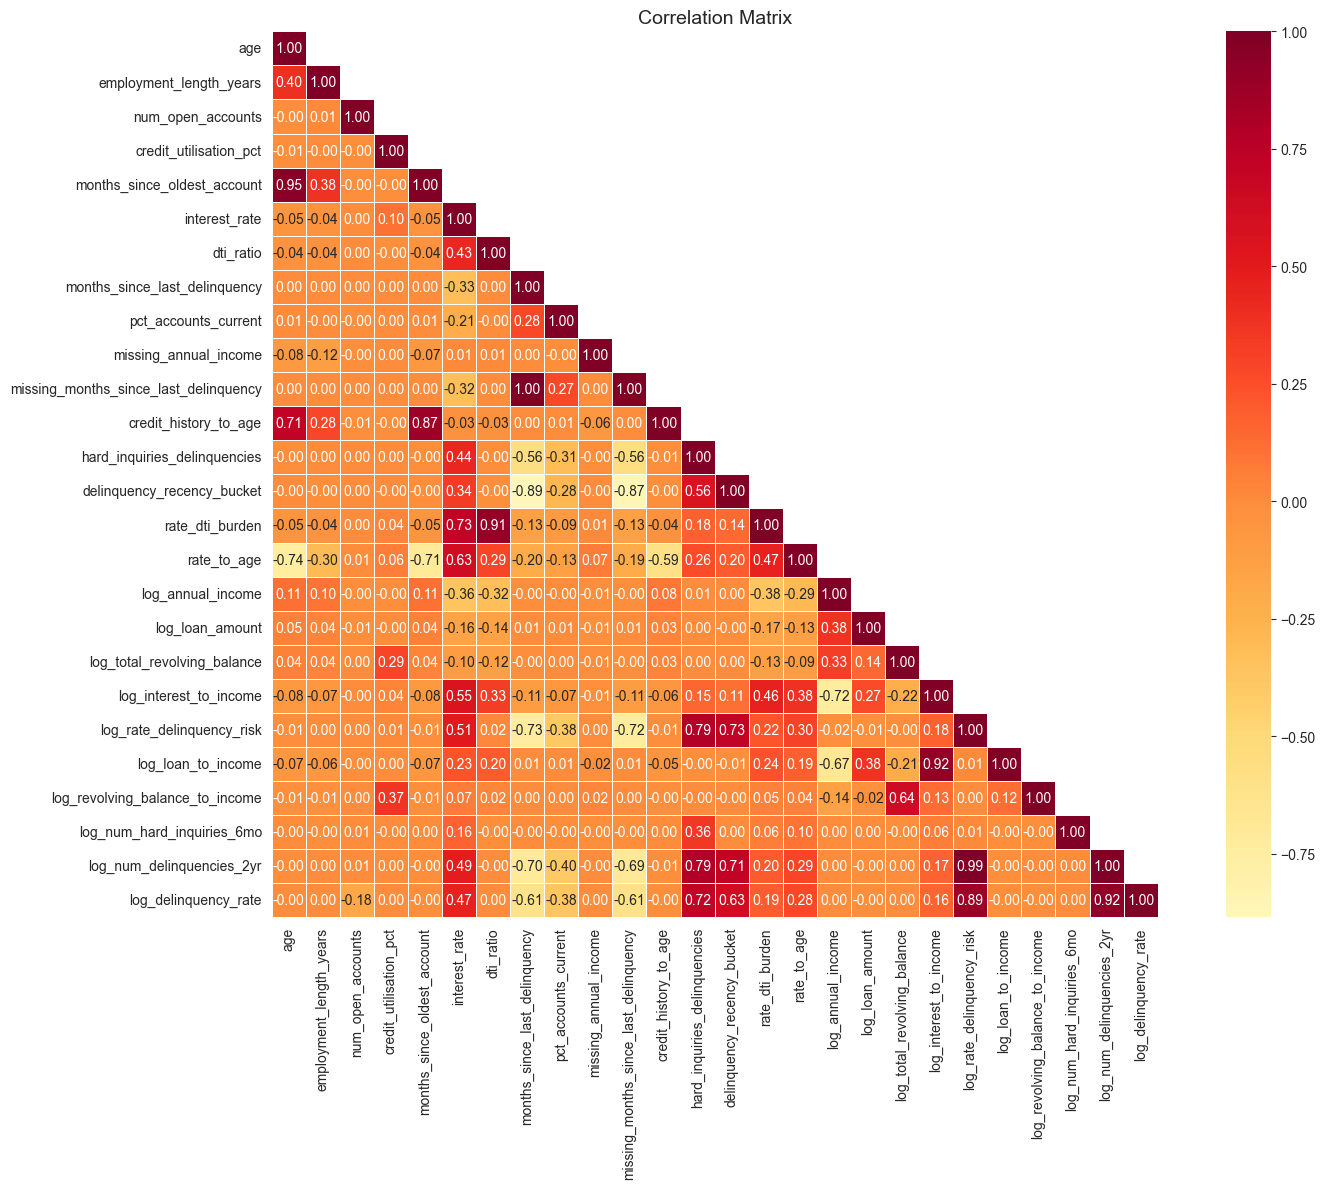

In [44]:
#lets check for multicolinearity using a correlation heatmap.

sns.set_style("white")

corr = df_train.drop(columns=["default_flag"]).corr()

mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask, k=1)] = True

plt.figure(figsize=(16, 12))
sns.heatmap(corr, mask=mask, cmap='YlOrRd', annot=True, fmt='.2f', center=0, linewidths=0.5, square=True)
plt.title('Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

In [45]:
#using the general rule of removing features with a correlation above 0.7 and 

drop_autocorrelation = ["months_since_oldest_account", "dti_ratio", 'log_delinquency_rate', 'delinquency_recency_bucket' ]

df_train = df_train.drop(columns=drop_autocorrelation)
df_test = df_test.drop(columns=drop_autocorrelation)

In [46]:
def calculate_iv(df, feature, target, bins=10):

    # bin variables
    df_temp = df[[feature, target]].copy()
    df_temp['bin'] = pd.qcut(df_temp[feature], q=bins, duplicates='drop')
    
    grouped = df_temp.groupby('bin')[target].agg(['sum', 'count'])
    grouped.columns = ['events', 'total']
    grouped['non_events'] = grouped['total'] - grouped['events']
    
    # ensuure no division by zero
    total_events = grouped['events'].sum()
    total_non_events = grouped['non_events'].sum()
    
    grouped['event_rate'] = grouped['events'] / total_events
    grouped['non_event_rate'] = grouped['non_events'] / total_non_events
    
    # ensure no log of zero
    grouped['event_rate'] = grouped['event_rate'].replace(0, 0.0001)
    grouped['non_event_rate'] = grouped['non_event_rate'].replace(0, 0.0001)
    
    grouped['woe'] = np.log(grouped['event_rate'] / grouped['non_event_rate'])
    grouped['iv'] = (grouped['event_rate'] - grouped['non_event_rate']) * grouped['woe']
    
    return grouped['iv'].sum(), grouped[['event_rate', 'non_event_rate', 'woe', 'iv']]

In [47]:
exclude = ['default_flag']

results = {}
for col in df_train.columns:
    if col not in exclude:
        try:
            iv, _ = calculate_iv(df_train, col, 'default_flag')
            results[col] = iv
        except:
            pass

# sort by IV
iv_df = pd.DataFrame.from_dict(results, orient='index', columns=['IV'])
iv_df = iv_df.sort_values('IV', ascending=False)
print(iv_df)

                                             IV
rate_to_age                            0.598945
interest_rate                          0.405542
months_since_last_delinquency          0.400794
log_annual_income                      0.358631
log_rate_delinquency_risk              0.331947
log_interest_to_income                 0.323939
age                                    0.252348
rate_dti_burden                        0.241603
log_num_delinquencies_2yr              0.240349
credit_history_to_age                  0.173667
employment_length_years                0.166047
log_loan_to_income                     0.162858
pct_accounts_current                   0.094870
num_open_accounts                      0.083718
log_revolving_balance_to_income        0.076296
credit_utilisation_pct                 0.056126
log_loan_amount                        0.053327
log_num_hard_inquiries_6mo             0.053309
log_total_revolving_balance            0.046514
missing_annual_income                  0

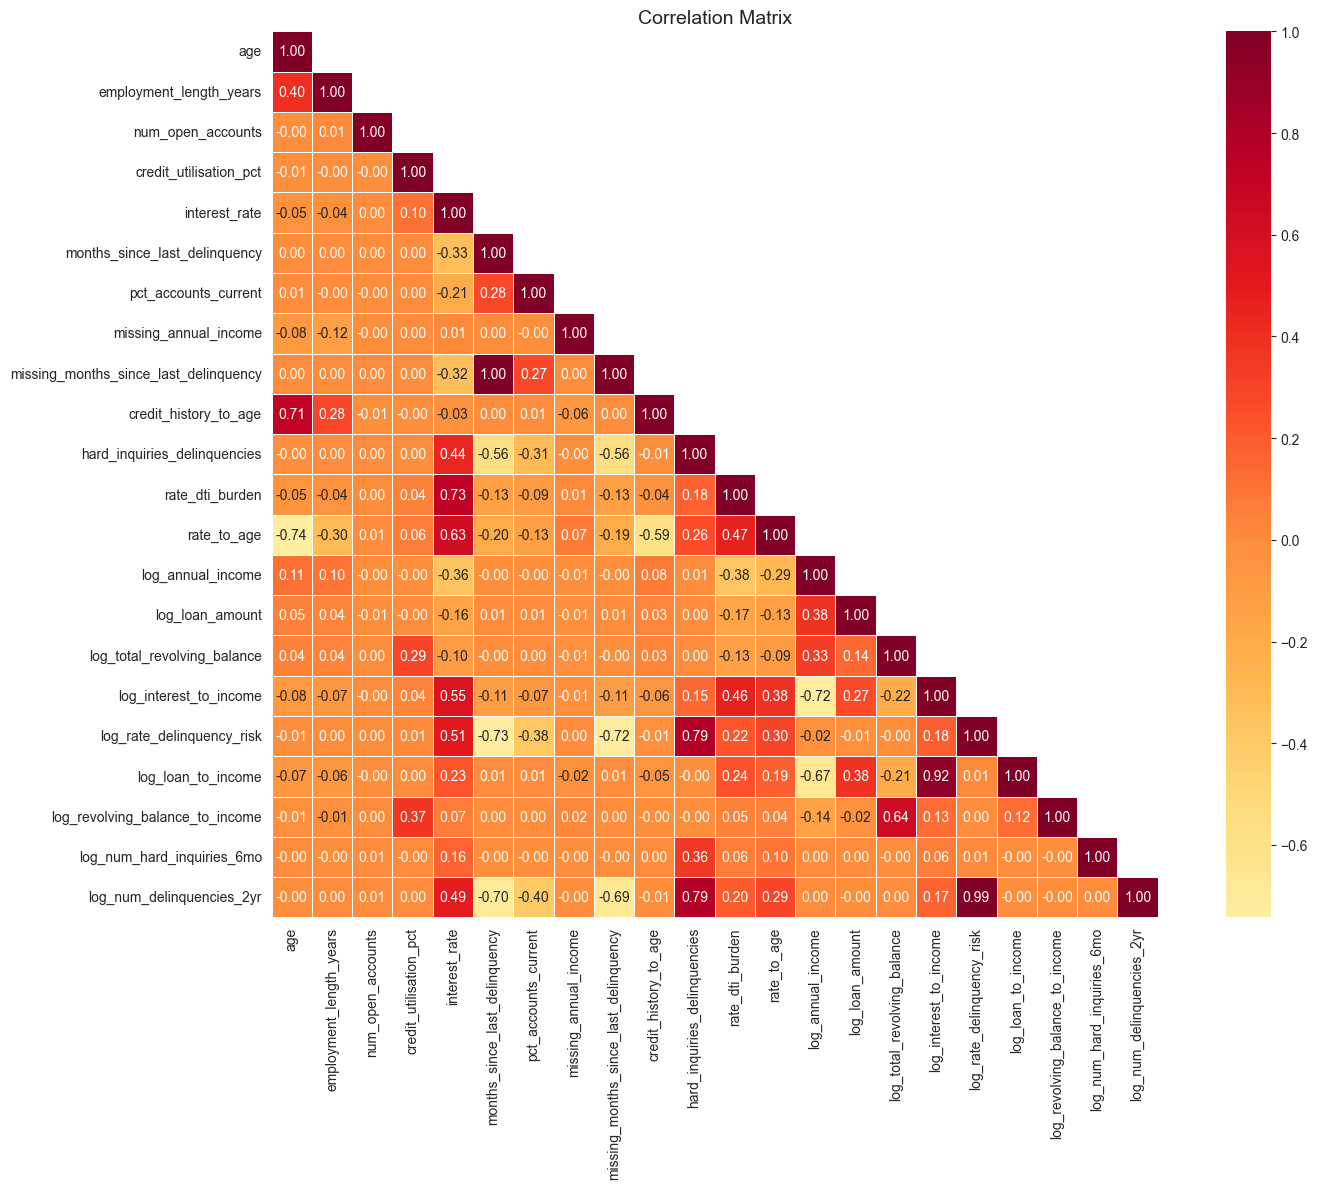

In [48]:
sns.set_style("white")

corr = df_train.drop(columns=["default_flag"]).corr()

mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask, k=1)] = True

plt.figure(figsize=(16, 12))
sns.heatmap(corr, mask=mask, cmap='YlOrRd', annot=True, fmt='.2f', center=0, linewidths=0.5, square=True)
plt.title('Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

In [51]:
autocorrelation = ["log_rate_delinquency_risk", "log_loan_to_income"]
df_train = df_train.drop(columns=autocorrelation)
df_test = df_test.drop(columns=autocorrelation)

In [52]:
df_train.to_csv("C:/Users/mutch_lf652j0/Credit Score Interactive Model/data/processed/engineered_train.csv", index=False)
df_test.to_csv("C:/Users/mutch_lf652j0/Credit Score Interactive Model/data/processed/engineered_test.csv", index=False)